## Setting Environment

In [57]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import pickle

## Initialise Data

In [59]:
trade = pd.read_excel("export_2021m1.xlsx", skiprows=1, index_col=0, nrows=7)
trade

,Canada,France,Germany,Italy,Japan,United Kingdom,United States
Canada,NaN,182.352251,415.434050,181.372819,800.140783,1524.279961,26703.649930
France,295.809053,NaN,6499.882449,3609.601611,671.496776,2212.457674,3008.172497
Germany,765.305670,9564.520318,NaN,6580.061189,1804.535371,5353.747032,10348.494982
Italy,331.691543,4508.622422,5843.193709,NaN,687.903268,1543.974658,3610.256816
Japan,664.301920,525.365888,1515.356257,365.072103,NaN,875.286681,10645.095673
United Kingdom,370.041409,1568.474303,2563.928364,749.513129,588.939467,NaN,4036.455558
United States,21217.187629,1996.406425,4516.721760,1815.032006,6017.644718,4670.679914,NaN


## Pre-Processing
1. Convert matrix data into pair data
2. Rename columns
3. Remove empty values

In [61]:
trade = pd.melt(trade.reset_index(), id_vars='index')
trade.columns=['exportCountry','importCountry','value']
trade.dropna(inplace=True)
trade.head()

,exportCountry,importCountry,value
1,France,Canada,295.809053
2,Germany,Canada,765.305670
3,Italy,Canada,331.691543
4,Japan,Canada,664.301920
5,United Kingdom,Canada,370.041409


## Create Network Graph Template
1. Initialise network graph
2. For loop to create nodes for the first 2 columns and the weight for value column
3. Remove isolated vertices (if any)
4. Setting size and colors of graph

In [63]:
G = nx.Graph()

for index, row in trade.iterrows():
    G.add_edge(row['exportCountry'], row['importCountry'], weight=row['value'])

    remove=[node for node, degree in G.degree() if degree==0]
    G.remove_nodes_from(remove)

    settings = {
    'node_color': 'orange',
    'edge_color': 'orange',
    'node_size': 1,
    'width': 1,
    'alpha': 1.0}

## Create Network Graph

### Spring Layout

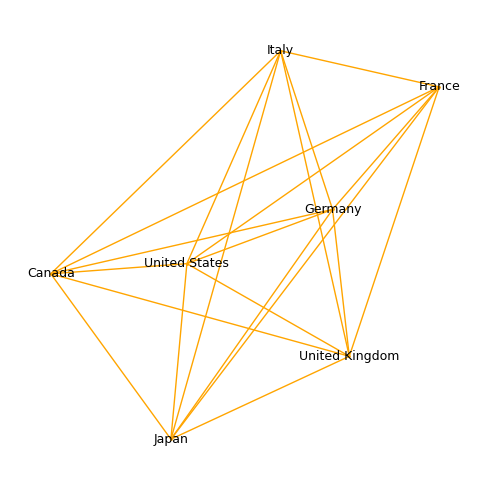

In [66]:
plt.subplots(figsize=(5,5))
pos=nx.spring_layout(G)

nx.draw(G,pos=pos, font_size=9, **settings)
nx.draw_networkx_labels(G, pos=pos, font_size=9)
plt.tight_layout()
plt.axis('off')
plt.show()

### Random Layout

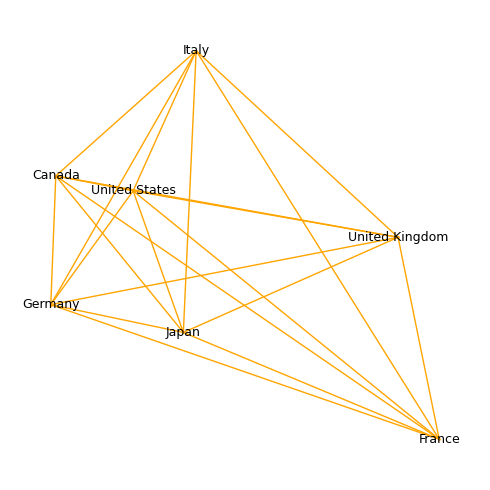

In [68]:
plt.subplots(figsize=(5,5))

pos=nx.random_layout(G)
nx.draw(G,pos=pos, font_size=9,**settings)
nx.draw_networkx_labels(G, pos=pos, font_size=9)
plt.tight_layout()
plt.axis('off')
plt.show()

### Circular Layout

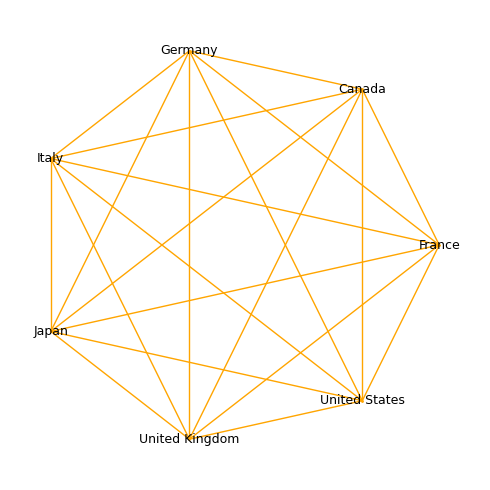

In [70]:
plt.subplots(figsize=(5,5))

pos=nx.circular_layout(G)
nx.draw(G,pos=pos, font_size=9, **settings)
nx.draw_networkx_labels(G,pos=pos, font_size=9)
plt.tight_layout()
plt.axis('off')
plt.show()

## Save Graph

In [72]:
f = open("graph.pickle", "wb")
pickle.dump(G, file=f)
f.close()